<a name="top" id="top"></a>

<div align="center">
    <h1>Quantum Annealing via D-Wave</h1>
    <a href="https://github.com/bernalde">David E. Bernal Neira</a>
    <br>
    <i>Davidson School of Chemical Engineering, Purdue University</i>
    <br>
    <br>
    <a href="https://github.com/pedromxavier">Pedro Maciel Xavier</a>
    <br>
    <i>Davidson School of Chemical Engineering, Purdue University</i>
    <br>
    <br>
    <a href="https://colab.research.google.com/github/JuliaQUBO/QUBONotebooks/blob/main/notebooks_jl/4-DWave.ipynb" target="_parent">
        <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
    </a>
    <a href="#installation">
        <img src="https://img.shields.io/badge/⚙️-Installation_Instructions-blue" alt="Installation Instructions"/>
    </a>
    <a href="https://secquoia.github.io/">
        <img src="https://img.shields.io/badge/🌲⚛️🌐-SECQUOIA-blue" alt="SECQUOIA"/>
    </a>
</div>

### Activate Environment

In [1]:
import Pkg; Pkg.activate(@__DIR__) # Here we go!

  Activating project at `~/repos/QUBONotebooks/notebooks_jl`


## About this Notebook

This notebook will give the first interaction with D-Wave's Quantum Annealer.
It will use the QUBO modeling problem introduced earlier and will define it using **[JuMP](https://jump.dev)**, and then solve them using neal's implementation of simulated annealing classicaly and D-Wave system package to use Quantum Annealing.
We will also leverage the use of **[Graphs.jl](https://github.com/JuliaGraphs/Graphs.jl)** for network models/graphs.

## Problem statement

We define a QUBO as the following optimization problem:

$$
\min_{x \in \{0,1 \}^n} \sum_{(ij) \in E(G)} Q_{ij}x_i x_j + \sum_{i \in V(G)}Q_{ii}x_i + \beta = \min_{x \in \{0,1 \}^n}  \mathbf{x}' \mathbf{Q} \mathbf{x} + \beta
$$

where we optimize over binary variables $x \in \{ 0,1 \}^n$, on a constrained graph $G(V,E)$ defined by a weighted adjacency matrix $\mathbf{Q}$.
We also include an arbitrary offset  $\beta$.

### Example

Suppose we want to solve the following problem via QUBO

$$
\begin{array}{rl}
\displaystyle%
\min_{\mathbf{x}} & 2x_0+4x_1+4x_2+4x_3+4x_4+4x_5+5x_6+4x_7+5x_8+6x_9+5x_{10} \\
\textrm{s.t.}     & \begin{bmatrix}
1 & 0 & 0 & 1 & 1 & 1 & 0 & 1 & 1 & 1 & 1\\
0 & 1 & 0 & 1 & 0 & 1 & 1 & 0 & 1 & 1 & 1\\
0 & 0 & 1 & 0 & 1 & 0 & 1 & 1 & 1 & 1 & 1
\end{bmatrix}\mathbf{x}=
\begin{bmatrix}
1\\
1\\
1
\end{bmatrix} \\
~ & \mathbf{x} \in \{0,1 \}^{11}
\end{array}
$$

First we would write this problem as a an unconstrained one by penalizing the linear constraints as quadratics in the objective.
Let's first define the problem parameters.

In [2]:
A = [
    1 0 0 1 1 1 0 1 1 1 1
    0 1 0 1 0 1 1 0 1 1 1
    0 0 1 0 1 0 1 1 1 1 1
]
b = [1, 1, 1]
c = [2, 4, 4, 4, 4, 4, 5, 4, 5, 6, 5];

In order to define the $\mathbf{Q}$ matrix, we first write the problem

$$
\begin{array}{rl}
    \displaystyle%
    \min_{\mathbf{x}} &\mathbf{c}' \mathbf{x} \\
    \textrm{s.t.}     & \mathbf{A}\mathbf{x} = \mathbf{b} \\
    ~                 & \mathbf{x} \in \{0,1 \}^{11}
\end{array}
$$

as follows:

$$
\begin{array}{rl}
    \displaystyle%
    \min_{\mathbf{x}} & \mathbf{c}' \mathbf{x} + \rho (\mathbf{A}\mathbf{x}-\mathbf{b})' (\mathbf{A}\mathbf{x}-\mathbf{b}) \\
    \textrm{s.t.}     & \mathbf{x} \in \{0,1 \}^{11}
\end{array}
$$

Exploiting the fact that $x^2=x$ for $x \in \{0,1\}$, we can make the linear terms appear in the diagonal of the $\mathbf{Q}$ matrix.

$$
\rho(\mathbf{A}\mathbf{x}-\mathbf{b})'(\mathbf{A}\mathbf{x}-\mathbf{b}) = \rho( \mathbf{x}'(\mathbf{A}'\mathbf{A}) \mathbf{x} - 2(\mathbf{A}'\mathbf{b}) \mathbf{x} + \mathbf{b}'\mathbf{b} )
$$

For this problem in particular, one can prove that a reasonable penalization factor is given by $\rho = \sum_{i=1}^n |c_i| + \epsilon$ with $\epsilon > 0$.

In [3]:
using LinearAlgebra

In [4]:
ϵ = 1
ρ = sum(abs, c) + ϵ
Q = diagm(c) + ρ * (A'A - 2 * diagm(A'b))
β = ρ * b'b

display(Q)
println(β)

11×11 Matrix{Int64}:
 -46    0    0   48   48   48    0   48    48    48    48
   0  -44    0   48    0   48   48    0    48    48    48
   0    0  -44    0   48    0   48   48    48    48    48
  48   48    0  -92   48   96   48   48    96    96    96
  48    0   48   48  -92   48   48   96    96    96    96
  48   48    0   96   48  -92   48   48    96    96    96
   0   48   48   48   48   48  -91   48    96    96    96
  48    0   48   48   96   48   48  -92    96    96    96
  48   48   48   96   96   96   96   96  -139   144   144
  48   48   48   96   96   96   96   96   144  -138   144
  48   48   48   96   96   96   96   96   144   144  -139

144


We can visualize the graph that defines this instance using the Q matrix as the adjacency matrix of a graph.

In [5]:
using Plots
using JuMP
using QUBO
using DWave

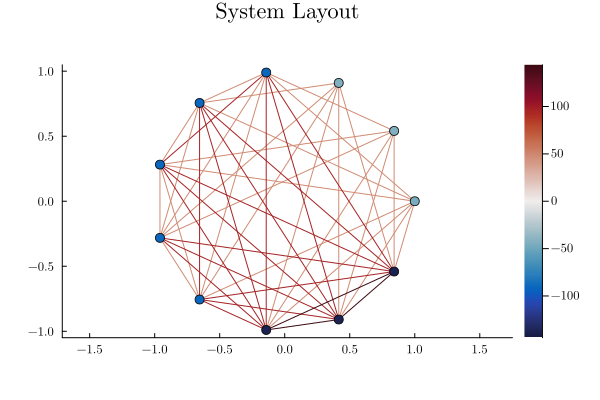

In [6]:
plot(QUBOTools.SystemLayoutPlot(Q))

Let's define a QUBO model and then solve it via simulated annealing.

In [7]:
using JuMP
using QUBO
using DWave

In [8]:
# Define empty model
qubo_model = Model()

# Define the variables
@variable(qubo_model, x[1:11], Bin)

# Define the objective function
@objective(qubo_model, Min, x' * Q * x + β)

# Print the model
print(qubo_model)

In [9]:
# Use D-Wave's simulated annealer 'Neal'
set_optimizer(qubo_model, DWave.Neal.Optimizer)

set_optimizer_attribute(qubo_model, "num_reads", 1_000)

optimize!(qubo_model)

println("Minimum energy: $(objective_value(qubo_model))")

Minimum energy: 5.0


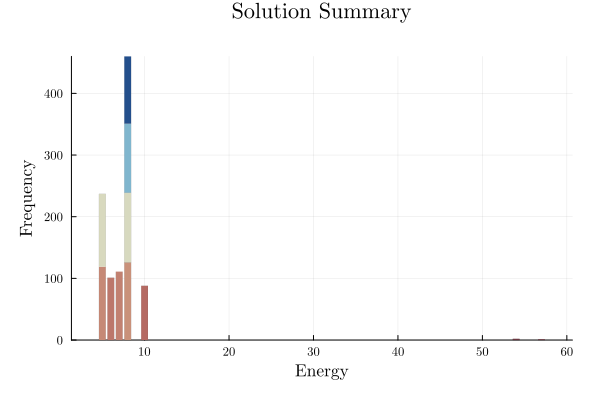

In [10]:
plot(QUBOTools.EnergyFrequencyPlot(qubo_model))

Notice that this is the same example we have been solving earlier (via Integer Programming in the Quiz 2, via Ising model and QUBO in Notebook 2).

## Now let's solve this using Quantum Annealing!

First, we start by defining the `DWAVE_API_TOKEN` environment variable.

In [11]:
if !haskey(ENV, "DWAVE_API_TOKEN")
    ENV["DWAVE_API_TOKEN"] = "<YOUR_KEY_HERE>"
end;

In [12]:
# Use D-Wave's quantum annealer
sampler = DWave.dwave_system.DWaveSampler(
    token=ENV["DWAVE_API_TOKEN"],
    solver=Dict("qpu" => true),
)
embedding_sampler = DWave.dwave_system.EmbeddingComposite(sampler)

set_optimizer(qubo_model, DWave.Optimizer)

set_optimizer_attribute(qubo_model, "sampler", embedding_sampler)
set_optimizer_attribute(qubo_model, "num_reads", 1024)

optimize!(qubo_model)

println("Minimum energy: $(objective_value(qubo_model))")

Minimum energy: 5.0


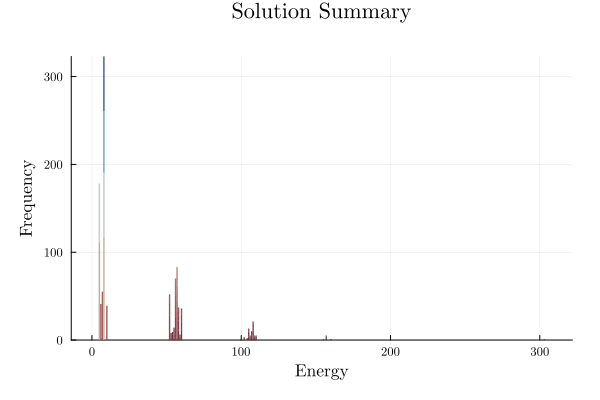

In [13]:
plot(QUBOTools.EnergyFrequencyPlot(qubo_model))

In [14]:
import Cairo, Fontconfig
using Graphs
using GraphPlot
import PythonCall: pyconvert, pyimport

In [15]:
# Reuse the QPU selected for the quantum annealing solve above.
sampler

Python: <dwave.system.samplers.dwave_sampler.DWaveSampler object at 0x78faa9781970>

Solver id:     Advantage_system6;graph_id=01dae5a273
Topology:      pegasus, shape=[16]
Working graph: 5612 qubits, 40088 couplers
Plotting induced subgraph on first 500 nodes: 2724 couplers


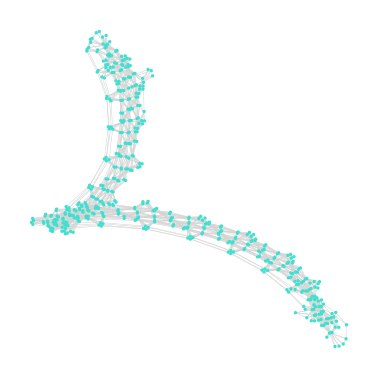

In [16]:
function networkx_edges(graph_py)
    builtins = pyimport("builtins")
    nodes = pyconvert(Vector{Int}, builtins.list(graph_py.nodes()))
    edges = pyconvert(Vector{Tuple{Int, Int}}, builtins.list(graph_py.edges()))

    return nodes, edges
end

function graph_from_edges(nodes, edges)
    node_index = Dict(node => index for (index, node) in enumerate(nodes))
    graph = SimpleGraph(length(nodes))

    for (u, v) in edges
        add_edge!(graph, node_index[u], node_index[v])
    end

    return graph
end

function draw_topology(sampler; max_nodes=500)
    topology = sampler.properties["topology"]
    topology_type = pyconvert(String, topology["type"])
    topology_shape = pyconvert(Vector{Int}, topology["shape"])
    nodes, edges = networkx_edges(sampler.to_networkx_graph())

    println("Solver id:     $(pyconvert(String, sampler.solver.id))")
    println("Topology:      $(topology_type), shape=$(topology_shape)")
    println("Working graph: $(length(nodes)) qubits, $(length(edges)) couplers")

    display_nodes = nodes
    display_edges = edges

    if length(nodes) > max_nodes
        display_nodes = nodes[1:max_nodes]
        display_node_set = Set(display_nodes)
        display_edges = [(u, v) for (u, v) in edges if u in display_node_set && v in display_node_set]
        println("Plotting induced subgraph on first $(max_nodes) nodes: $(length(display_edges)) couplers")
    end

    display_graph = graph_from_edges(display_nodes, display_edges)

    return gplot(
        display_graph;
        nodelabel=nothing,
        nodesize=0.2,
        edgelinewidth=0.1,
    )
end

draw_topology(sampler)

In [17]:
sol = QUBOTools.solution(unsafe_backend(qubo_model).model)

QUBOTools.SampleSet{Float64, Int64} with 91 samples:
  QUBOTools.Sample{Float64, Int64}([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1], 5.0, 111)
  QUBOTools.Sample{Float64, Int64}([0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0], 5.0, 67)
  QUBOTools.Sample{Float64, Int64}([0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0], 6.0, 41)
  QUBOTools.Sample{Float64, Int64}([1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0], 7.0, 55)
  QUBOTools.Sample{Float64, Int64}([0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0], 8.0, 116)
  QUBOTools.Sample{Float64, Int64}([0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0], 8.0, 75)
  QUBOTools.Sample{Float64, Int64}([0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0], 8.0, 70)
  QUBOTools.Sample{Float64, Int64}([0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0], 8.0, 62)
  QUBOTools.Sample{Float64, Int64}([1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0], 10.0, 39)
  ⋮


In [18]:
data = QUBOTools.metadata(sol)
info = get(data, "dwave_info", nothing)

Dict{String, Any} with 3 entries:
  "timing"     => Dict{String, Any}("qpu_delay_time_per_sample"=>20.58, "post_p…
  "chip_info"  => Dict{String, Any}("chip_id"=>"Advantage_system6", "topology"=…
  "problem_id" => "b8ef7bfc-ef69-431e-8eaa-a757447732c0"

Now we can play with the other parameters such as Annealing time, chain strenght, and annealing schedule to improve the performance of D-Wave's Quantum Annealing.

# References

- [Julia Colab Notebook Template](https://colab.research.google.com/github/ageron/julia_notebooks/blob/master/Julia_Colab_Notebook_Template.ipynb)
- [QuIPML22](https://github.com/bernalde/QuIPML22/)

<a name="installation" id="installation"></a>

# Installation

## Colab Instructions

If not in a Colab notebook, continue to the next section.

1. Work on a copy of this notebook: _File_ > _Save a copy in Drive_ (you will need a Google account). Alternatively, you can download the notebook using _File_ > _Download .ipynb_, then upload it to [Colab](https://colab.research.google.com/).
2. Execute the following cell (click on it and press Ctrl+Enter) to install Julia, IJulia and other required packages. This can take a couple of minutes.
3. Reload this page (press Ctrl+R, or ⌘+R, or the F5 key) and continue to the next section.

If your Colab Runtime gets reset (e.g., due to inactivity), repeat steps 2 and 3.

In [ ]:
%%shell

bash <(curl -s "https://raw.githubusercontent.com/JuliaQUBO/QUBONotebooks/main/scripts/install-colab-julia.sh")

## Validate Installation

In [ ]:
versioninfo()

## Local Installation Instructions

If you don't have a Julia installation yet, consider using [juliaup](https://github.com/JuliaLang/juliaup).
Otherwise, run the next cell to install the necessary packages.

### Install Julia Packages

In [ ]:
import Pkg

Pkg.activate(@__DIR__)
Pkg.instantiate(; io = devnull) # Suppress Output

<div align="center">
    <a href="#top">🔝 Go back to the top 🔝</a>
</div>